EDA using the PEMS-BAY traffic dataset which contains data from 325 traffic sensors in the Bay area from January to June of 2017.

Step 1: Set up required packages

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gc

Step 2: Establish path (independent of device) and verify

In [2]:
ROOT = Path.cwd()

# Allows notebook to work whether Jupyter was launched
# from the repository root or from notebooks/
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

RAW_DIR = ROOT / "data" / "raw"

SPEED_FILE = RAW_DIR / "pems_bay_speed.csv"
METADATA_FILE = RAW_DIR / "pems_bay_sensor_metadata.csv"

print(SPEED_FILE.exists())
print(METADATA_FILE.exists())

True
True


Step 3: Load the speed data

In [3]:
speed_raw = pd.read_csv(SPEED_FILE, index_col=0)

print(speed_raw.shape)
speed_raw.head()

(325, 52116)


,2017-01-01 00:00:00,2017-01-01 00:05:00,2017-01-01 00:10:00,2017-01-01 00:15:00,2017-01-01 00:20:00,2017-01-01 00:25:00,2017-01-01 00:30:00,2017-01-01 00:35:00,2017-01-01 00:40:00,2017-01-01 00:45:00,...,2017-06-30 23:10:00,2017-06-30 23:15:00,2017-06-30 23:20:00,2017-06-30 23:25:00,2017-06-30 23:30:00,2017-06-30 23:35:00,2017-06-30 23:40:00,2017-06-30 23:45:00,2017-06-30 23:50:00,2017-06-30 23:55:00
400001,71.4,71.6,71.6,71.1,71.7,71.2,71.3,70.5,71.5,70.7,...,72.3,71.8,71.7,71.6,71.3,70.9,71.3,71.4,72.2,71.5
400017,67.8,67.5,67.6,67.5,67.8,67.4,67.6,67.6,67.5,67.4,...,65.7,66.0,65.1,65.9,66.3,66.3,66.6,66.9,66.5,66.2
400030,70.5,70.6,70.2,70.3,70.2,70.3,70.1,70.6,70.5,70.5,...,68.5,68.5,66.8,68.6,68.2,68.4,68.7,68.1,68.0,68.4
400040,67.4,67.5,67.4,68.0,68.1,67.5,67.2,68.1,67.6,68.3,...,60.4,61.0,61.1,61.2,60.6,61.0,60.9,61.1,61.1,61.5
400045,68.8,68.7,68.7,68.5,68.4,68.4,68.5,68.4,68.3,68.5,...,61.5,62.5,61.3,61.3,61.1,61.8,62.0,62.0,62.5,62.8


Step 4: Transpose the above matrix to have each of the 325 sensors as a column and each timestamp as a row.

In [4]:
speed = speed_raw.T.copy()

speed.index = pd.to_datetime(speed.index)
speed.index.name = "timestamp"

speed.columns = speed.columns.astype(str)
speed = speed.sort_index()

del speed_raw
gc.collect()

# 32-bit floats are more than sufficient for traffic speeds
speed = speed.astype("float32")

speed.head()

,400001,400017,400030,400040,400045,400052,400057,400059,400065,400069,...,409525,409526,409528,409529,413026,413845,413877,413878,414284,414694
timestamp,,,,,,,,,,,,,,,,,,,,,
2017-01-01 00:00:00,71.400002,67.800003,70.500000,67.400002,68.800003,66.599998,66.800003,68.000000,66.800003,69.000000,...,68.800003,67.900002,68.800003,68.000000,69.199997,68.900002,70.400002,68.800003,71.099998,68.000000
2017-01-01 00:05:00,71.599998,67.500000,70.599998,67.500000,68.699997,66.599998,66.800003,67.800003,66.500000,68.199997,...,68.400002,67.300003,68.400002,67.599998,70.400002,68.800003,70.099998,68.400002,70.800003,67.400002
2017-01-01 00:10:00,71.599998,67.599998,70.199997,67.400002,68.699997,66.099998,66.800003,67.800003,66.199997,67.800003,...,68.400002,67.400002,68.400002,67.500000,70.199997,68.300003,69.800003,68.400002,70.500000,67.900002
2017-01-01 00:15:00,71.099998,67.500000,70.300003,68.000000,68.500000,66.699997,66.599998,67.699997,65.900002,67.800003,...,68.500000,67.500000,68.500000,67.500000,70.400002,68.699997,70.199997,68.400002,70.800003,67.599998
2017-01-01 00:20:00,71.699997,67.800003,70.199997,68.099998,68.400002,66.900002,66.099998,67.699997,66.099998,67.800003,...,68.500000,67.699997,68.500000,67.400002,69.599998,69.099998,70.000000,68.400002,71.000000,67.900002


In [5]:
print("Shape:", speed.shape)
print("Number of sensors:", speed.shape[1])
print("Start:", speed.index.min())
print("End:", speed.index.max())
print("Duplicate timestamps:", speed.index.duplicated().sum())

Shape: (52116, 325)
Number of sensors: 325
Start: 2017-01-01 00:00:00
End: 2017-06-30 23:55:00
Duplicate timestamps: 0


Step 5: Verify 5-minute intervals are the dominant cadence

In [6]:
speed.dtypes.value_counts()
time_steps = speed.index.to_series().diff()

time_steps.value_counts().head()

timestamp
0 days 00:05:00    52114
0 days 01:05:00        1
Name: count, dtype: int64

In [7]:
n_missing = speed.isna().sum().sum()
n_total = speed.size

missing_fraction = n_missing / n_total

print(f"Missing observations: {n_missing:,}")
print(f"Total observations: {n_total:,}")
print(f"Missing fraction: {missing_fraction:.4%}")

Missing observations: 521
Total observations: 16,937,700
Missing fraction: 0.0031%


In [8]:
missing_by_sensor = (
    speed.isna()
    .mean()
    .sort_values(ascending=False)
)

missing_by_sensor.describe()

count    325.000000
mean       0.000031
std        0.000019
min        0.000000
25%        0.000019
50%        0.000038
75%        0.000038
max        0.000077
dtype: float64

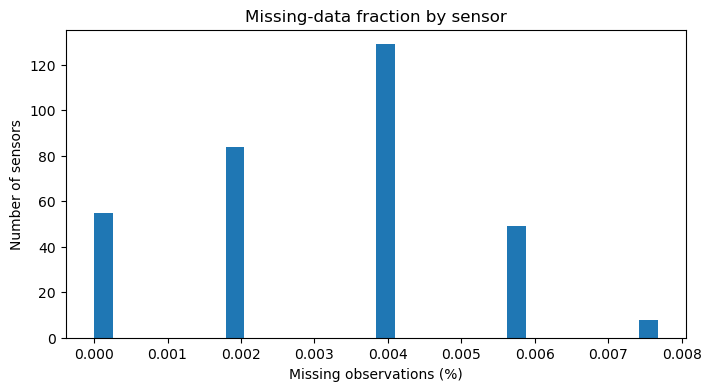

In [9]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.hist(missing_by_sensor * 100, bins=30)

ax.set_xlabel("Missing observations (%)")
ax.set_ylabel("Number of sensors")
ax.set_title("Missing-data fraction by sensor")

plt.show()

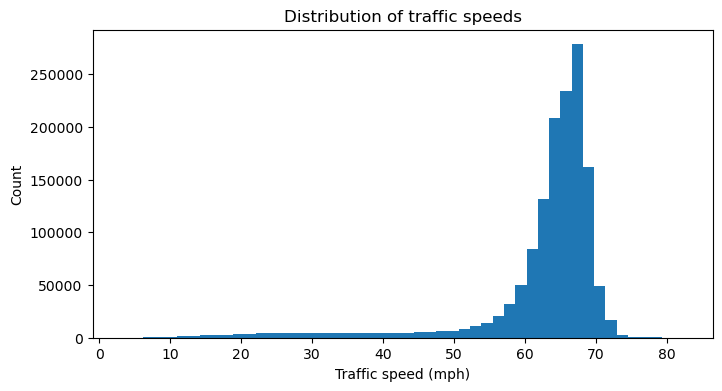

<Figure size 640x480 with 0 Axes>

In [11]:
speed_sample = speed.iloc[::12]
values = speed_sample.to_numpy().ravel()
values = values[~np.isnan(values)]

fig, ax = plt.subplots(figsize=(8, 4))

ax.hist(values, bins=50)

ax.set_xlabel("Traffic speed (mph)")
ax.set_ylabel("Count")
ax.set_title("Distribution of traffic speeds")

plt.show()
plt.savefig("speed_dist.jpg")

As expected, the distribution has its dominant peak around ~68 mph. However, there is a low-velocity tail below ~50 mph going all the way down to ~5 mph that is of great interest to us. This is most likely the low speed congestion tail. Next, let us look at how the mean speed varies by time and day.

C:\Users\abhis\AppData\Local\Temp\ipykernel_58752\3901176757.py:4: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`). Please use a specific unit instead.
  end = start + pd.Timedelta(days=7)


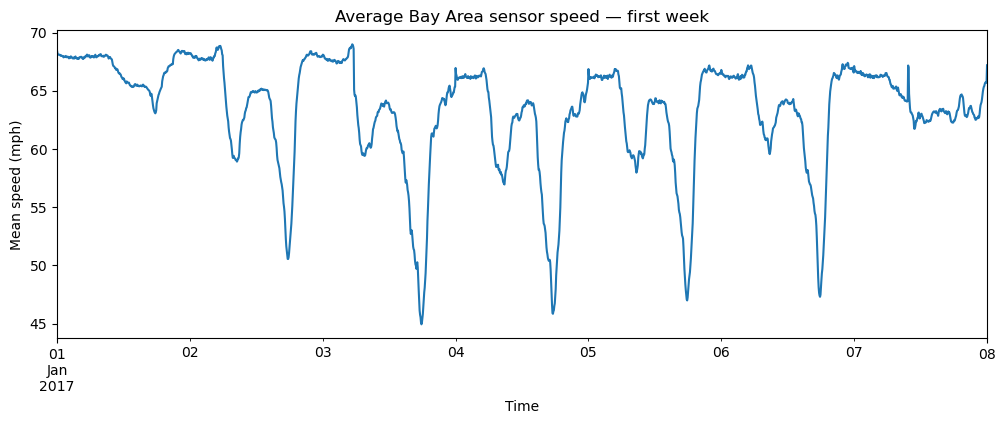

In [13]:
network_mean_speed = speed.mean(axis=1)

start = speed.index.min()
end = start + pd.Timedelta(days=7)

fig, ax = plt.subplots(figsize=(12, 4))

network_mean_speed.loc[start:end].plot(ax=ax)

ax.set_ylabel("Mean speed (mph)")
ax.set_xlabel("Time")
ax.set_title("Average Bay Area sensor speed — first week")

plt.show()

Clearly, we can see some recurring patterns. Now, let us focus on the average DAILY pattern to see if we can spot slowdowns during rush hour, etc.

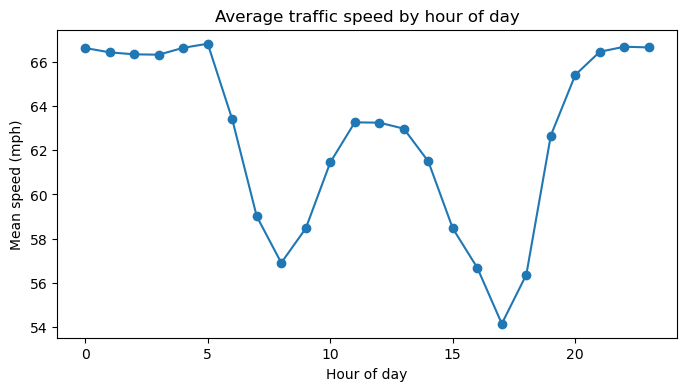

In [14]:
daily_profile = network_mean_speed.groupby(
    network_mean_speed.index.hour
).mean()

fig, ax = plt.subplots(figsize=(8, 4))

daily_profile.plot(ax=ax, marker="o")

ax.set_xlabel("Hour of day")
ax.set_ylabel("Mean speed (mph)")
ax.set_title("Average traffic speed by hour of day")

plt.show()

Selected sensor: 400017
Coverage: 100.00%


C:\Users\abhis\AppData\Local\Temp\ipykernel_58752\1289390771.py:14: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`). Please use a specific unit instead.
  end = start + pd.Timedelta(days=3)


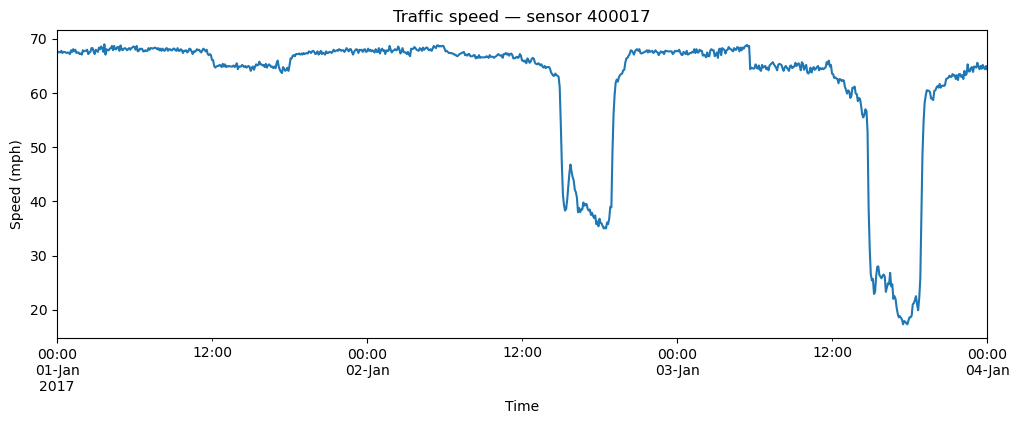

In [15]:
sensor_coverage = speed.notna().mean()

sensor_id = sensor_coverage.idxmax()

print("Selected sensor:", sensor_id)
print(
    "Coverage:",
    f"{sensor_coverage.loc[sensor_id]:.2%}"
)

sensor_series = speed[sensor_id]

start = sensor_series.index.min()
end = start + pd.Timedelta(days=3)

fig, ax = plt.subplots(figsize=(12, 4))

sensor_series.loc[start:end].plot(ax=ax)

ax.set_xlabel("Time")
ax.set_ylabel("Speed (mph)")
ax.set_title(f"Traffic speed — sensor {sensor_id}")

plt.show()

Here we are looking at the data from one specific sensor with particularly good coverage to see if the speed drops are sharper than in the mean. Now, let us probe whether a 30-minute forecast is possible. Note that this corresponds to six 5-minute intervals.

          speed_now  speed_30min_future
count  52110.000000        52110.000000
mean      59.018223           59.018093
std       13.250700           13.250621
min       11.000000           11.000000
25%       62.200001           62.200001
50%       64.000000           64.000000
75%       65.099998           65.099998
max       71.599998           71.599998
                    speed_now  speed_30min_future
speed_now            1.000000            0.912627
speed_30min_future   0.912627            1.000000


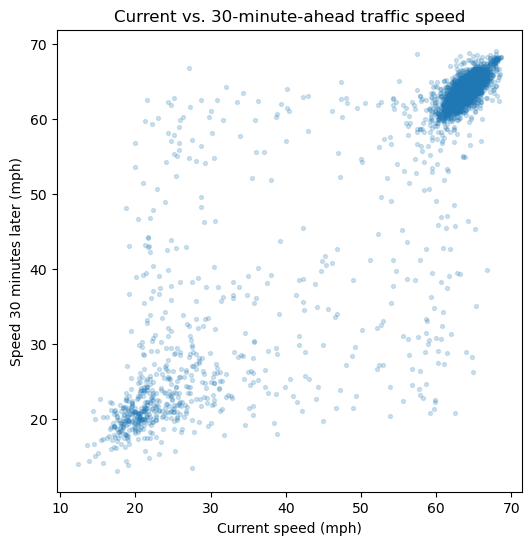

In [18]:
forecast_check = pd.DataFrame({
    "speed_now": sensor_series,
    "speed_30min_future": sensor_series.shift(-6)
}).dropna()

print(forecast_check.describe())

print(forecast_check.corr())

plot_sample = forecast_check.sample(
    n=min(5000, len(forecast_check)),
    random_state=42
)

fig, ax = plt.subplots(figsize=(6, 6))

ax.scatter(
    plot_sample["speed_now"],
    plot_sample["speed_30min_future"],
    alpha=0.2,
    s=8
)

ax.set_xlabel("Current speed (mph)")
ax.set_ylabel("Speed 30 minutes later (mph)")
ax.set_title("Current vs. 30-minute-ahead traffic speed")

plt.show()

In [17]:
errors = (
    forecast_check["speed_30min_future"]
    - forecast_check["speed_now"]
)

persistence_mae = errors.abs().mean()
persistence_rmse = np.sqrt((errors ** 2).mean())

print(f"Persistence MAE:  {persistence_mae:.2f} mph")
print(f"Persistence RMSE: {persistence_rmse:.2f} mph")

Persistence MAE:  2.12 mph
Persistence RMSE: 5.54 mph


At first glance, the mean absolute error is the better KPI. Further verification is required.

## Initial Findings

- The dataset contains 325 sensors covering January 1, 2017 to June 30,2017.
- Measurements are recorded predominantly at 5-minute intervals.
- Overall missingness is 0.0031%.
- Traffic speed shows clear daily temporal structure.
- Individual sensors exhibit periods of substantial speed reduction
  consistent with congestion.
- Current speed and speed 30 minutes later have a correlation of 0.91.
- A persistence forecast produces an MAE of 2.12 mph and RMSE of 5.54 mph.

## Next Steps

1. Use sensor metadata to define a single freeway corridor.
2. Examine traffic behavior along neighboring sensors.
3. Finalize forecasting KPIs based on the observed target distribution.
4. Establish chronological training/validation/test sets.
5. Compare persistence against linear and tree-based baseline models.